# А 1 БЛОК 1: ИНИЦИАЛИЗАЦИЯ БАЗЫ ДАННЫХ

## Импорты и инициализация переменных

In [1]:
import requests
import pandas as pd
import sqlite3
import numpy as np
import geopandas as gpd
from shapely.geometry import Point
import os
import json
import gc
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import warnings
import seaborn as sns
from scipy import stats
import hashlib

# --- КОНФИГУРАЦИЯ ---
DB_PATH = 'ev_championship.db'
DATA_DIR = './data'
MAPS_DIR = './maps'
os.makedirs(MAPS_DIR, exist_ok=True)

YANDEX_API_KEY = "0dbaa950-5547-4353-b143-202d54edcb87"
MAX_MAP_REQUESTS = 5
maps_created_counter = 0

### Функция дедупликации

In [2]:
def upsert_df_to_sql(df, table_name, conn, key_columns, chunksize=5000):
    """
    Умная вставка: UPDATE существующих, INSERT новых.
    key_columns — список колонок для проверки уникальности (PRIMARY KEY или составной ключ)
    """
    if len(df) == 0:
        print(f"[UPSERT] {table_name}: нет данных для вставки")
        return 0

    cursor = conn.cursor()

    # Получаем существующие ключи
    key_str = ', '.join(key_columns)
    cursor.execute(f"SELECT {key_str} FROM {table_name}")
    existing_keys = set()
    for row in cursor.fetchall():
        # Для составного ключа — кортеж, для одиночного — значение
        existing_keys.add(row[0] if len(row) == 1 else tuple(row))

    # Определяем новые и существующие записи
    def get_key(row):
        if len(key_columns) == 1:
            return row[key_columns[0]]
        return tuple(row[col] for col in key_columns)

    df['_key'] = df.apply(get_key, axis=1)

    df_new = df[~df['_key'].isin(existing_keys)].copy()
    df_existing = df[df['_key'].isin(existing_keys)].copy()

    inserted = 0
    updated = 0

    # INSERT новых
    if len(df_new) > 0:
        df_new_clean = df_new.drop(columns=['_key'])
        df_new_clean.to_sql(f'{table_name}_temp', conn, if_exists='replace', index=False, chunksize=chunksize)
        cursor.execute(f'INSERT INTO {table_name} SELECT * FROM {table_name}_temp')
        inserted = len(df_new)
        cursor.execute(f'DROP TABLE {table_name}_temp')
        print(f"[UPSERT] {table_name}: вставлено {inserted} новых")

    # UPDATE существующих (для таблиц где это имеет смысл)
    if len(df_existing) > 0 and table_name in ['vehicles', 'weather', 'routes']:
        # Для справочников — обновляем данные
        df_existing_clean = df_existing.drop(columns=['_key'])
        df_existing_clean.to_sql(f'{table_name}_temp', conn, if_exists='replace', index=False, chunksize=chunksize)

        # Получаем колонки
        cursor.execute(f"PRAGMA table_info({table_name})")
        all_columns = [row[1] for row in cursor.fetchall()]
        update_columns = [c for c in all_columns if c not in key_columns]

        # SQLite не поддерживает UPDATE с JOIN напрямую, используем REPLACE
        # Удаляем старые записи и вставляем новые
        for key in df_existing['_key'].unique():
            if len(key_columns) == 1:
                cursor.execute(f"DELETE FROM {table_name} WHERE {key_columns[0]} = ?", (key,))
            else:
                conditions = ' AND '.join([f"{k} = ?" for k in key_columns])
                cursor.execute(f"DELETE FROM {table_name} WHERE {conditions}", key)

        cursor.execute(f'INSERT INTO {table_name} SELECT * FROM {table_name}_temp')
        updated = len(df_existing)
        cursor.execute(f'DROP TABLE {table_name}_temp')
        print(f"[UPSERT] {table_name}: обновлено {updated} существующих")

    conn.commit()
    return inserted + updated


def check_and_create_table(conn, table_name, create_sql):
    """Проверяет существование таблицы, создаёт если нет"""
    cursor = conn.cursor()
    cursor.execute(f"SELECT name FROM sqlite_master WHERE type='table' AND name='{table_name}'")
    if not cursor.fetchone():
        cursor.execute(create_sql)
        conn.commit()
        print(f"[INIT] Создана таблица: {table_name}")
        return True
    return False

## БЛОК 1: Создаем базу данных

Создали таблицы для автомобилей, погоды, маршурутов, телематики и карт

In [3]:
conn = sqlite3.connect(DB_PATH)
cursor = conn.cursor()
# Таблица vehicles — справочник ТС
check_and_create_table(conn, 'vehicles', '''
    CREATE TABLE vehicles (
        vehicle_id TEXT PRIMARY KEY,
        model TEXT,
        battery_capacity_kwh REAL,
        year_of_manufacture INTEGER,
        battery_health REAL,
        driving_style TEXT,
        initial_odometer_km REAL,
        has_problem INTEGER,
        problem_type TEXT,
        problem_severity REAL
    )
''')

# Таблица weather — справочник погоды по датам
check_and_create_table(conn, 'weather', '''
    CREATE TABLE weather (
        date TEXT PRIMARY KEY,
        avg_temperature_c REAL,
        precipitation_mm REAL,
        humidity_percent REAL,
        wind_speed_kmh REAL
    )
''')

# Таблица routes — маршруты с картами
check_and_create_table(conn, 'routes', '''
    CREATE TABLE routes (
        route_id TEXT PRIMARY KEY,
        vehicle_id TEXT,
        planned_start TEXT,
        planned_end TEXT,
        route_type TEXT,
        expected_distance_km REAL,
        map_image_path TEXT,
        geojson TEXT,
        FOREIGN KEY (vehicle_id) REFERENCES vehicles (vehicle_id)
    )
''')

# Таблица telematics — сырые телематические данные
check_and_create_table(conn, 'telematics', '''
    CREATE TABLE telematics (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        vehicle_id TEXT,
        route_id TEXT,
        timestamp TEXT,
        latitude REAL,
        longitude REAL,
        speed_kmh REAL,
        battery_soc_percent REAL,
        energy_consumption_kwh_per_100km REAL,
        temperature_c REAL,
        precipitation_mm REAL,
        FOREIGN KEY (route_id) REFERENCES routes (route_id)
    )
''')

# Таблица map_features — гео-объекты
check_and_create_table(conn, 'map_features', '''
    CREATE TABLE map_features (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        feature_type TEXT,
        properties TEXT,
        geometry TEXT
    )
''')
conn.commit()
conn.close()

[INIT] Создана таблица: vehicles
[INIT] Создана таблица: weather
[INIT] Создана таблица: routes
[INIT] Создана таблица: telematics
[INIT] Создана таблица: map_features


## БЛОК 2: ЗАГРУЗКА ДАННЫХ В БАЗУ

## Подключение к базе данных

In [4]:
conn = sqlite3.connect(DB_PATH)

## ЗАГРУЗКА АВТОМОБИЛЕЙ

In [7]:
## ЗАГРУЗКА АВТОМОБИЛЕЙ С ДЕДУПЛИКАЦИЕЙ

try:
    df_vehicles = pd.read_csv(os.path.join(DATA_DIR, 'new_vehicles.csv'))

    conn = sqlite3.connect(DB_PATH)
    upsert_df_to_sql(df_vehicles, 'vehicles', conn, ['vehicle_id'])
    conn.close()
    print("[1/5] Автомобили: загружены")
except Exception as e:
    print(f"[SKIP] Автомобили: {e}")

[UPSERT] vehicles: вставлено 1 новых
[UPSERT] vehicles: обновлено 5 существующих
[1/5] Автомобили: загружены


## ЗАГРУЗКА ПОГОДЫ

In [8]:
## ЗАГРУЗКА ПОГОДЫ С ДЕДУПЛИКАЦИЕЙ

try:
    df_weather = pd.read_csv(os.path.join(DATA_DIR, 'weather.csv'))

    conn = sqlite3.connect(DB_PATH)
    upsert_df_to_sql(df_weather, 'weather', conn, ['date'])
    conn.close()
    print("[2/5] Погода: загружена")
except Exception as e:
    print(f"[SKIP] Погода: {e}")

[UPSERT] weather: вставлено 180 новых
[2/5] Погода: загружена


### ЗАГРУЗКА МАРШРУТОВ С КАРТАМИ

In [9]:
## ЗАГРУЗКА МАРШРУТОВ С КАРТАМИ И ДЕДУПЛИКАЦИЕЙ

try:
    df_routes = pd.read_csv(os.path.join(DATA_DIR, 'routes.csv'))

    # Загружаем GeoJSON с детальными маршрутами
    json_path = os.path.join(DATA_DIR, 'routes_full.json')
    geo_dict = {}

    if os.path.exists(json_path):
        with open(json_path, 'r', encoding='utf-8') as f:
            routes_geo = json.load(f)
        features_list = routes_geo if isinstance(routes_geo, list) else routes_geo.get('features', [])
        for item in features_list:
            r_id = item.get('route_id') or item.get('properties', {}).get('route_id') or item.get('id')
            if r_id:
                geo_dict[str(r_id)] = item

    print(f"[DEBUG] Объектов в JSON: {len(geo_dict)}")

    routes_list = []
    matches = 0

    for _, row in df_routes.iterrows():
        r_id = str(row['route_id'])
        geo_feature = geo_dict.get(r_id)
        map_path = None
        geo_json_str = None

        if geo_feature:
            matches += 1
            geo_json_str = json.dumps(geo_feature)
            coords = None

            if 'planned_path' in geo_feature:
                val = geo_feature['planned_path']
                if isinstance(val, dict) and 'coordinates' in val:
                    coords = val['coordinates']
                elif isinstance(val, list):
                    coords = val

            if not coords:
                sp = geo_feature.get('start_point')
                ep = geo_feature.get('end_point')
                if sp and ep:
                    coords = [sp, ep]

            # Генерация карты (без изменений)
            if coords and maps_created_counter < MAX_MAP_REQUESTS:
                filename = f"route_{r_id}.png"
                full_path = os.path.join(MAPS_DIR, filename)

                if not os.path.exists(full_path) and len(coords) >= 2:
                    try:
                        lons = [c[0] for c in coords]
                        lats = [c[1] for c in coords]
                        min_lon, max_lon = min(lons), max(lons)
                        min_lat, max_lat = min(lats), max(lats)
                        center_lon = (min_lon + max_lon) / 2
                        center_lat = (min_lat + max_lat) / 2
                        span_lon = max(max_lon - min_lon, 0.005) * 1.2
                        span_lat = max(max_lat - min_lat, 0.005) * 1.2
                        step = max(1, len(coords) // 50)
                        simplified_coords = coords[::step]
                        polyline_str = ",".join([f"{lon:.5f},{lat:.5f}" for lon, lat in simplified_coords])
                        start_pt = f"{simplified_coords[0][0]:.5f},{simplified_coords[0][1]:.5f},pm2rdm"
                        end_pt = f"{simplified_coords[-1][0]:.5f},{simplified_coords[-1][1]:.5f},pm2blm"
                        pt_param = f"{start_pt}~{end_pt}"

                        base_url = "https://static-maps.yandex.ru/1.x/"
                        params = {
                            "l": "map",
                            "ll": f"{center_lon:.5f},{center_lat:.5f}",
                            "spn": f"{span_lon:.5f},{span_lat:.5f}",
                            "size": "650,450",
                            "pl": polyline_str,
                            "pt": pt_param,
                            "apikey": YANDEX_API_KEY
                        }

                        response = requests.get(base_url, params=params, timeout=10)

                        if response.status_code == 200:
                            with open(full_path, 'wb') as f:
                                f.write(response.content)
                            maps_created_counter += 1
                            map_path = full_path
                            print(f"[YANDEX] КАРТА СОЗДАНА #{maps_created_counter}: {r_id}")
                        else:
                            print(f"[YANDEX] Ошибка {response.status_code} для {r_id}")

                    except Exception as e:
                        print(f"[YANDEX] Крит. ошибка: {e}")

        routes_list.append({
            'route_id': r_id,
            'vehicle_id': row['vehicle_id'],
            'planned_start': row['planned_start'],
            'planned_end': row['planned_end'],
            'route_type': row['route_type'],
            'expected_distance_km': row['expected_distance_km'],
            'map_image_path': map_path,
            'geojson': geo_json_str
        })

    # Дедупликация через UPSERT
    conn = sqlite3.connect(DB_PATH)
    df_routes_to_upsert = pd.DataFrame(routes_list)
    upsert_df_to_sql(df_routes_to_upsert, 'routes', conn, ['route_id'])
    conn.close()

    print(f"[3/5] Маршруты: обработано {len(routes_list)}. Совпадений с GeoJSON: {matches}. Карт: {maps_created_counter}")

except Exception as e:
    import traceback
    print(f"[ERR] Маршруты: {e}")
    traceback.print_exc()

[DEBUG] Объектов в JSON: 17655
[YANDEX] КАРТА СОЗДАНА #1: R00015_EV003
[YANDEX] КАРТА СОЗДАНА #2: R00011_EV004
[YANDEX] КАРТА СОЗДАНА #3: R00012_EV004
[YANDEX] КАРТА СОЗДАНА #4: R00013_EV004
[YANDEX] КАРТА СОЗДАНА #5: R00014_EV004
[UPSERT] routes: вставлено 17655 новых
[3/5] Маршруты: обработано 17655. Совпадений с GeoJSON: 17655. Карт: 5


## ЗАГРУЗКА ТЕЛЕМАТИКИ

In [10]:
## ЗАГРУЗКА ТЕЛЕМАТИКИ С ДЕДУПЛИКАЦИЕЙ И АВТО-МАППИНГОМ КОЛОНОК

try:
    df_tel = pd.read_csv(os.path.join(DATA_DIR, 'telematics_full.csv'), low_memory=False)
    print(f"[DEBUG] Загружено из CSV: {len(df_tel):,} строк")
    print(f"[DEBUG] Колонки в CSV: {list(df_tel.columns)}")

    conn = sqlite3.connect(DB_PATH)
    cursor = conn.cursor()

    # Получаем существующие колонки в таблице
    cursor.execute("PRAGMA table_info(telematics)")
    existing_columns = {row[1] for row in cursor.fetchall()}
    print(f"[DEBUG] Колонки в БД: {existing_columns}")

    # Приводим названия колонок к единому формату (snake_case, нижний регистр)
    df_tel.columns = df_tel.columns.str.lower().str.strip()

    # Маппинг возможных вариантов названий
    column_mapping = {
        'lat': 'latitude',
        'lon': 'longitude',
        'lng': 'longitude',
        'speed': 'speed_kmh',
        'soc': 'battery_soc_percent',
        'battery_soc': 'battery_soc_percent',
        'consumption': 'energy_consumption_kwh_per_100km',
        'temp': 'temperature_c',
        'temp_c': 'temperature_c',
        'odometer': 'odometer_km',
        'mileage': 'odometer_km',
        'precipitation': 'precipitation_mm',
        'rain': 'precipitation_mm'
    }

    # Переименовываем колонки
    df_tel = df_tel.rename(columns=column_mapping)

    # Оставляем только колонки, которые есть в БД (чтобы не было ошибки)
    csv_columns = set(df_tel.columns)
    valid_columns = csv_columns & existing_columns
    ignored_columns = csv_columns - existing_columns

    if ignored_columns:
        print(f"[WARN] Пропущены колонки (нет в БД): {ignored_columns}")

    df_tel = df_tel[list(valid_columns)]
    print(f"[DEBUG] Используем колонки: {list(valid_columns)}")

    # Нормализация timestamp для корректной дедупликации
    if 'timestamp' in df_tel.columns:
        # Приводим к единому формату ISO
        df_tel['timestamp'] = pd.to_datetime(df_tel['timestamp'], errors='coerce').dt.strftime('%Y-%m-%d %H:%M:%S')
        # Удаляем строки с некорректными датами
        before_clean = len(df_tel)
        df_tel = df_tel.dropna(subset=['timestamp'])
        if len(df_tel) < before_clean:
            print(f"[CLEAN] Удалено строк с некорректным timestamp: {before_clean - len(df_tel)}")

    # Дедупликация по составному ключу vehicle_id + timestamp
    key_cols = ['vehicle_id', 'timestamp']
    if all(col in df_tel.columns for col in key_cols):
        # Удаляем дубликаты внутри самого CSV
        before_dedup = len(df_tel)
        df_tel = df_tel.drop_duplicates(subset=key_cols, keep='first')
        inner_dedup = before_dedup - len(df_tel)
        if inner_dedup > 0:
            print(f"[DEDUP] Дубликатов внутри CSV: {inner_dedup:,} ({inner_dedup/before_dedup*100:.1f}%)")

        # Получаем существующие записи из БД
        cursor.execute("SELECT vehicle_id, timestamp FROM telematics")
        existing_pairs = set(cursor.fetchall())
        print(f"[DEBUG] Уже в БД: {len(existing_pairs):,} записей")

        # Фильтруем только новые
        df_tel['_key'] = list(zip(df_tel['vehicle_id'], df_tel['timestamp']))
        df_tel_new = df_tel[~df_tel['_key'].isin(existing_pairs)].copy()
        df_tel_new = df_tel_new.drop(columns=['_key'])

        skipped = len(df_tel) - len(df_tel_new)

        # Вставляем чанками
        if len(df_tel_new) > 0:
            df_tel_new.to_sql('telematics', conn, if_exists='append', index=False, chunksize=5000)
            print(f"[4/5] Телематика: вставлено {len(df_tel_new):,} новых, пропущено {skipped:,} дубликатов")
        else:
            print(f"[4/5] Телематика: все записи уже существуют (пропущено {skipped:,})")
    else:
        # Нет ключевых колонок — просто дописываем (риск дублей!)
        print(f"[WARN] Нет колонок {key_cols}, вставка без проверки дубликатов!")
        df_tel.to_sql('telematics', conn, if_exists='append', index=False, chunksize=5000)
        print(f"[4/5] Телематика: вставлено {len(df_tel):,} строк (без проверки дубликатов)")

    conn.close()

except Exception as e:
    import traceback
    print(f"[ERR] Телематика: {e}")
    traceback.print_exc()

[DEBUG] Загружено из CSV: 3,258,239 строк
[DEBUG] Колонки в CSV: ['vehicle_id', 'route_id', 'timestamp', 'latitude', 'longitude', 'speed_kmh', 'battery_soc_percent', 'energy_consumption_kwh_per_100km', 'odometer_km', 'temperature_c', 'precipitation_mm', 'humidity_percent', 'wind_speed_kmh', 'acceleration_mps2', 'route_type', 'day_of_week', 'is_weekend', 'has_problem', 'problem_type', 'energy_per_km_wh', 'driving_style_score', 'driving_category', 'hour', 'time_of_day', 'season', 'battery_risk', 'efficiency_score', 'consumption_anomaly']
[DEBUG] Колонки в БД: {'route_id', 'vehicle_id', 'battery_soc_percent', 'temperature_c', 'longitude', 'precipitation_mm', 'timestamp', 'speed_kmh', 'latitude', 'id', 'energy_consumption_kwh_per_100km'}
[WARN] Пропущены колонки (нет в БД): {'driving_style_score', 'acceleration_mps2', 'consumption_anomaly', 'time_of_day', 'day_of_week', 'problem_type', 'season', 'hour', 'is_weekend', 'energy_per_km_wh', 'odometer_km', 'route_type', 'wind_speed_kmh', 'batte

## ЗАГРУЗКА ОБЪЕКТОВ КАРТЫ

### Парсим GeoJSON файл с дополнительными гео-объектами

In [11]:
## ЗАГРУЗКА ОБЪЕКТОВ КАРТЫ С ДЕДУПЛИКАЦИЕЙ

try:
    with open(os.path.join(DATA_DIR, 'map_data.geojson'), 'r', encoding='utf-8') as f:
        map_data = json.load(f)

    # Преобразуем каждый Feature в строку таблицы
    mf = []
    for f in map_data.get('features', []):
        # Создаём хеш геометрии как уникальный идентификатор
        geom_str = json.dumps(f['geometry'], sort_keys=True)
        geom_hash = hashlib.md5(geom_str.encode()).hexdigest()[:16]

        mf.append({
            'geometry_hash': geom_hash,  # Синтетический ключ
            'feature_type': f['geometry']['type'],
            'properties': json.dumps(f['properties']),
            'geometry': geom_str
        })

    conn = sqlite3.connect(DB_PATH)

    # Проверяем существование колонки geometry_hash, добавляем если нет
    cursor = conn.cursor()
    cursor.execute("PRAGMA table_info(map_features)")
    columns = [row[1] for row in cursor.fetchall()]

    if 'geometry_hash' not in columns:
        # Пересоздаём таблицу с новой структурой
        cursor.execute('DROP TABLE IF EXISTS map_features')
        cursor.execute('''
            CREATE TABLE map_features (
                geometry_hash TEXT PRIMARY KEY,
                feature_type TEXT,
                properties TEXT,
                geometry TEXT
            )
        ''')
        conn.commit()
        print("[INIT] Пересоздана таблица map_features с geometry_hash")

    df_map = pd.DataFrame(mf)
    upsert_df_to_sql(df_map, 'map_features', conn, ['geometry_hash'])

    print(f"[5/5] Объекты карты: обработано {len(mf)}")

except Exception as e:
    print(f"[SKIP] Объекты карты: {e}")

[INIT] Пересоздана таблица map_features с geometry_hash
[UPSERT] map_features: вставлено 81 новых
[5/5] Объекты карты: обработано 81


## Сохраняем изменения и закрываем соединение

In [12]:
conn.commit()
conn.close()

# A 2 БЛОК 0: ОТКЛЮЧЕНИЕ ПРЕДУПРЕЖДЕНИЙ

In [13]:
warnings.filterwarnings('ignore')

## БЛОК 1: ЗАГРУЗКА ДАННЫХ ИЗ БД С ОПТИМИЗАЦИЕЙ ТИПОВ ДЛЯ ЭКОНОМИИ ПАМЯТИ

### ПОДКЛЮЧЕНИЕ К БАЗЕ ДАННЫХ

In [14]:
conn = sqlite3.connect(DB_PATH)

### ЗАГРУЗКА ТЕЛЕМАТИКИ

In [15]:
query_tel = """
    SELECT
        vehicle_id,
        route_id,
        timestamp,
        latitude,
        longitude,
        speed_kmh,
        battery_soc_percent
    FROM telematics
"""

# Оптимизация: float32 вместо float64 экономит 50% памяти
dtype_tel = {
    'latitude': 'float32',
    'longitude': 'float32',
    'speed_kmh': 'float32',
    'battery_soc_percent': 'float32'
}
df_tel = pd.read_sql(query_tel, conn, dtype=dtype_tel)

### ЗАГРУЗКА МЕТЕОДАННЫХ

In [16]:
df_weather = pd.read_sql("SELECT date, avg_temperature_c FROM weather", conn)

### ЗАГРУЗКА ДАННЫХ АВТОМОБИЛЕЙ

In [17]:
# Характеристики ТС: ёмкость батареи и начальный пробег
dtype_veh = {
    'battery_capacity_kwh': 'float32',
    'initial_odometer_km': 'float32'
}
df_vehicles = pd.read_sql(
    "SELECT vehicle_id, battery_capacity_kwh, initial_odometer_km FROM vehicles",
    conn,
    dtype=dtype_veh
)

### ЗАГРУЗКА ГЕО-ОБЪЕКТОВ КАРТЫ И ЗАКРЫТИЕ ПОДКЛЮЧЕНИЯ

In [18]:
# GeoJSON данные для пространственного анализа (дороги, POI)
df_map_json = pd.read_sql("SELECT properties, geometry FROM map_features", conn)

# Закрываем соединение после загрузки всех данных
conn.close()

## # БЛОК 2: ПРИВЯЗКА ПОГОДНЫХ ДАННЫХ

### Обогащаем телематику температурой по дате

In [19]:
# Извлекаем дату из timestamp телематики
df_tel['date'] = pd.to_datetime(df_tel['timestamp']).dt.date
# Приводим дату погоды к тому же формату
df_weather['date'] = pd.to_datetime(df_weather['date']).dt.date
# LEFT JOIN: сохраняем все записи телематики, даже без погоды
df_tel = df_tel.merge(df_weather, on='date', how='left')

## БЛОК 3: РАСЧЁТ ФИЗИЧЕСКИХ ХАРАКТЕРИСТИК (КИНЕМАТИКА)

### Расчет 30-секундных интервалов

In [20]:
## БЛОК 3: РЕСЕМПЛИНГ НА 30-СЕКУНДНЫЕ ИНТЕРВАЛЫ И РАСЧЁТ ФИЗИКИ

print("\n=== РЕСЕМПЛИНГ НА 30-СЕКУНДНЫЕ ИНТЕРВАЛЫ ===")

# Сортируем перед группировкой
df_tel = df_tel.sort_values(by=['vehicle_id', 'route_id', 'timestamp'])
df_tel['timestamp'] = pd.to_datetime(df_tel['timestamp'])

# Определяем типы колонок
id_columns = ['vehicle_id', 'route_id']  # строковые идентификаторы
numeric_columns = ['latitude', 'longitude', 'speed_kmh', 'battery_soc_percent',
                   'avg_temperature_c', 'battery_capacity_kwh', 'initial_odometer_km']
# Фильтруем только существующие числовые колонки
numeric_columns = [c for c in numeric_columns if c in df_tel.columns]

print(f"[DEBUG] ID колонки: {id_columns}")
print(f"[DEBUG] Числовые колонки: {numeric_columns}")
print(f"[DEBUG] Исходное количество записей: {len(df_tel):,}")

# Группировка по маршрутам
grouped = df_tel.groupby(id_columns)
n_groups = len(grouped)
print(f"[DEBUG] Уникальных маршрутов: {n_groups}")

resampled_chunks = []

for i, ((vid, rid), group) in enumerate(grouped):
    if i % 100 == 0:
        print(f"  Обработка {i+1}/{n_groups}...")

    if len(group) < 2:
        # Слишком мало точек — пропускаем или берём как есть
        resampled_chunks.append(group)
        continue

    # Устанавливаем timestamp как индекс
    group = group.set_index('timestamp')

    # Ресемплинг: только числовые колонки усредняем
    # Для ID берём первое значение (они константны внутри группы)
    resampled_numeric = group[numeric_columns].resample('30S').mean()

    # Интерполяция пропусков
    resampled_numeric = resampled_numeric.interpolate(method='linear', limit_direction='both')

    # Добавляем ID колонки (forward fill — берём ближайшее известное)
    for col in id_columns:
        resampled_numeric[col] = group[col].resample('30S').first().ffill()


    # Сбрасываем индекс, чтобы timestamp стал колонкой
    resampled = resampled_numeric.reset_index()

    resampled_chunks.append(resampled)

# Объединяем все ресемплированные чанки
df_tel = pd.concat(resampled_chunks, ignore_index=True)
df_tel['date'] = pd.to_datetime(df_tel['timestamp']).dt.date
print(f"После ресемплинга: {len(df_tel):,} записей")
print(f"Пример данных:\n{df_tel.head()}")



# Очистка памяти
del resampled_chunks
gc.collect()

print("=== РЕСЕМПЛИНГ ЗАВЕРШЁН ===\n")


=== РЕСЕМПЛИНГ НА 30-СЕКУНДНЫЕ ИНТЕРВАЛЫ ===
[DEBUG] ID колонки: ['vehicle_id', 'route_id']
[DEBUG] Числовые колонки: ['latitude', 'longitude', 'speed_kmh', 'battery_soc_percent', 'avg_temperature_c']
[DEBUG] Исходное количество записей: 2,759,104
[DEBUG] Уникальных маршрутов: 9331
  Обработка 1/9331...
  Обработка 101/9331...
  Обработка 201/9331...
  Обработка 301/9331...
  Обработка 401/9331...
  Обработка 501/9331...
  Обработка 601/9331...
  Обработка 701/9331...
  Обработка 801/9331...
  Обработка 901/9331...
  Обработка 1001/9331...
  Обработка 1101/9331...
  Обработка 1201/9331...
  Обработка 1301/9331...
  Обработка 1401/9331...
  Обработка 1501/9331...
  Обработка 1601/9331...
  Обработка 1701/9331...
  Обработка 1801/9331...
  Обработка 1901/9331...
  Обработка 2001/9331...
  Обработка 2101/9331...
  Обработка 2201/9331...
  Обработка 2301/9331...
  Обработка 2401/9331...
  Обработка 2501/9331...
  Обработка 2601/9331...
  Обработка 2701/9331...
  Обработка 2801/9331...
  О

### Вычисляем ускорение, расход энергии, одометр, стиль вождения

#### Добавляем ёмкость батареи для расчёта расхода

In [21]:
df_tel = df_tel.merge(df_vehicles, on='vehicle_id')

### ПОДГОТОВКА ВРЕМЕННЫХ РЯДОВ

#### Сортируем по машине и времени для корректного расчёта дельт

In [22]:
df_tel['timestamp'] = pd.to_datetime(df_tel['timestamp'])
df_tel = df_tel.sort_values(by=['vehicle_id', 'timestamp'])

### ФУНКЦИЯ HAVERSINE

#### Вычисляет расстояние между двумя точками на сфере (Земля)

In [23]:
def haversine(lat1, lon1, lat2, lon2):
    """
    Формула гаверсинусов для точного расчёта расстояния между координатами.
    R = 6371 км (радиус Земли).
    """
    R = 6371  # км
    phi1 = np.radians(lat1)
    phi2 = np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlambda/2)**2
    res = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
    return R * res

### СДВИГ ДАННЫХ ДЛЯ РАСЧЁТА ДЕЛЬТ

#### Создаём колонки с предыдущими значениями через groupby + shift

In [24]:
df_tel['prev_speed'] = df_tel.groupby('vehicle_id')['speed_kmh'].shift(1)
df_tel['prev_soc'] = df_tel.groupby('vehicle_id')['battery_soc_percent'].shift(1)
df_tel['prev_lat'] = df_tel.groupby('vehicle_id')['latitude'].shift(1)
df_tel['prev_lon'] = df_tel.groupby('vehicle_id')['longitude'].shift(1)
df_tel['time_diff_sec'] = df_tel.groupby('vehicle_id')['timestamp'].diff().dt.total_seconds()

### РАСЧЁТ ОДОМЕТРА (ПРОБЕГА)

#### Кумулятивная сумма расстояний между точками + начальный пробег

In [25]:
# Расстояние между текущей и предыдущей точкой
df_tel['delta_dist_km'] = haversine(
    df_tel['prev_lat'],
    df_tel['prev_lon'],
    df_tel['latitude'],
    df_tel['longitude']
)
# Накопленный пробег по каждой машине + начальный пробег из БД
df_tel['odometer'] = df_tel.groupby('vehicle_id')['delta_dist_km'].cumsum() + df_tel['initial_odometer_km']

### РАСЧЁТ УСКОРЕНИЯ

In [26]:
df_tel['acceleration'] = ((df_tel['speed_kmh'] - df_tel['prev_speed']) / 3.6) / df_tel['time_diff_sec']

### РАСЧЁТ РАСХОДА ЭНЕРГИИ (kWh/100km)

In [27]:
# Разница SOC (предыдущий - текущий). Если заряжались (SOC вырос) -> 0
df_tel['delta_soc'] = df_tel['prev_soc'] - df_tel['battery_soc_percent']
df_tel['delta_soc'] = df_tel['delta_soc'].apply(lambda x: x if x > 0 else 0)

# Энергия = (падение SOC в % / 100) * ёмкость батареи
df_tel['energy_used_kwh'] = (df_tel['delta_soc'] / 100) * df_tel['battery_capacity_kwh']

# Расход на 100 км: (энергия / км) * 100. Защита от деления на 0
df_tel['consumption_kwh_per_100km'] = (df_tel['energy_used_kwh'] / df_tel['delta_dist_km']) * 100
df_tel.loc[df_tel['delta_dist_km'] == 0, 'consumption_kwh_per_100km'] = 0

### ОПРЕДЕЛЕНИЕ СТИЛЯ ВОЖДЕНИЯ

#### Функция get_driving_style и применение

In [28]:
def get_driving_style(acc):
    """Классифицирует стиль вождения по величине ускорения"""
    if pd.isna(acc):
        return "Unknown"
    abs_acc = abs(acc)
    if abs_acc > 2.5:  # Резкое ускорение/торможение (> 2.5 м/с²)
        return "Aggressive"
    if abs_acc < 0.5:  # Почти равномерное движение
        return "Cruising"
    return "Normal"     # Средний режим

df_tel['driving_style'] = df_tel['acceleration'].apply(get_driving_style)

In [29]:
# 2. Колонки и типы данных
print(f"\n📋 Колонки ({len(df_tel.columns)}):")
for i, col in enumerate(df_tel.columns, 1):
    dtype = df_tel[col].dtype
    non_null = df_tel[col].notna().sum()
    null_pct = (1 - non_null/len(df_tel)) * 100
    print(f"   {i:2d}. {col:25s} | {str(dtype):10s} | {non_null:6,} не-null ({null_pct:5.1f}% пропусков)")


📋 Колонки (23):
    1. timestamp                 | datetime64[ns] | 2,845,867 не-null (  0.0% пропусков)
    2. latitude                  | float32    | 2,845,867 не-null (  0.0% пропусков)
    3. longitude                 | float32    | 2,845,867 не-null (  0.0% пропусков)
    4. speed_kmh                 | float32    | 2,845,867 не-null (  0.0% пропусков)
    5. battery_soc_percent       | float32    | 2,845,867 не-null (  0.0% пропусков)
    6. avg_temperature_c         | float64    | 2,845,867 не-null (  0.0% пропусков)
    7. vehicle_id                | object     | 2,845,867 не-null (  0.0% пропусков)
    8. route_id                  | object     | 2,845,867 не-null (  0.0% пропусков)
    9. date                      | object     |      1 не-null (100.0% пропусков)
   10. battery_capacity_kwh      | float32    | 2,845,867 не-null (  0.0% пропусков)
   11. initial_odometer_km       | float32    | 2,845,867 не-null (  0.0% пропусков)
   12. prev_speed                | float32    |

### ОЧИСТКА ВРЕМЕННЫХ КОЛОНОК

In [30]:
cols_to_drop = [
    'prev_speed',
    'prev_soc',
    'prev_lat',
    'prev_lon',
    'time_diff_sec',
    'delta_dist_km',
    'delta_soc',
    'energy_used_kwh'
]
df_enriched = df_tel.drop(columns=cols_to_drop)

## БЛОК 4: ПРОСТРАНСТВЕННОЕ ОБОГАЩЕНИЕ


### Привязываем точки телематики к дорогам и POI через GeoPandas

#### СОЗДАНИЕ GEODATAFRAME ИЗ ТЕЛЕМАТИКИ

In [31]:
# Преобразуем координаты в геометрию Point (EPSG:4326 - WGS84)
geometry = [Point(xy) for xy in zip(df_enriched.longitude, df_enriched.latitude)]
gdf_tel = gpd.GeoDataFrame(df_enriched, geometry=geometry, crs="EPSG:4326")

#### ПАРСИНГ GEOJSON КАРТЫ ИЗ БД

In [32]:
# Восстанавливаем GeoJSON структуру из строк БД
features = []
for _, row in df_map_json.iterrows():
    props = json.loads(row['properties'])
    geom = json.loads(row['geometry'])
    features.append({
        "type": "Feature",
        "properties": props,
        "geometry": geom
    })

# Если карта пустая - заполняем значениями по умолчанию и пропускаем геоанализ
if not features:
    print("[WARN] Карта пуста. Заполняем типы дорог 'Unknown'.")
    df_final = df_enriched.copy()
    df_final['road_type'] = 'Unknown'
    df_final['poi_distance_km'] = -1
else:
    # Создаём GeoDataFrame из объектов карты
    gdf_map = gpd.GeoDataFrame.from_features(features, crs="EPSG:4326")

#### ПОИСК БЛИЖАЙШЕЙ ДОРОГИ

In [33]:
roads = gpd.GeoDataFrame()
if 'type' in gdf_map.columns:
    roads = gdf_map[gdf_map['type'] == 'road']

if not roads.empty:
    # sjoin_nearest ищет ближайший объект и добавляет расстояние
    gdf_joined = gpd.sjoin_nearest(gdf_tel, roads, how='left', distance_col='dist_to_road')
    # Берём тип дороги из поля subtype, если нет - 'Unknown'
    gdf_joined['road_type'] = gdf_joined['subtype'].fillna('Unknown')

    # ФИКС: Удаляем index_right перед вторым соединением чтобы избежать конфликта имён
    if 'index_right' in gdf_joined.columns:
        gdf_joined = gdf_joined.drop(columns=['index_right'])
else:
    gdf_joined = gdf_tel.copy()
    gdf_joined['road_type'] = 'Unknown'

#### ПОИСК БЛИЖАЙШЕГО POI

In [34]:
# Точки интереса: зарядки, склады и т.д. (всё что не дороги)
pois = gpd.GeoDataFrame()
if 'type' in gdf_map.columns:
    pois = gdf_map[gdf_map['type'] != 'road']

if not pois.empty:
    # Второй spatial join для поиска ближайшего POI
    # index_right уже удалён, конфликта не будет
    gdf_final = gpd.sjoin_nearest(gdf_joined, pois, how='left', distance_col='dist_to_poi')

    # Переводим расстояние из градусов в километры (1° ≈ 111 км на экваторе)
    gdf_final['poi_distance_km'] = gdf_final['dist_to_poi'] * 111
else:
    gdf_final = gdf_joined.copy()
    gdf_final['poi_distance_km'] = -1

#### ОЧИСТКА И ФИНАЛИЗАЦИЯ

In [35]:
cols_to_drop = [
        'index_right',      # Индекс объекта карты (POI)
        'dist_to_road',     # Техническое расстояние до дороги
        'dist_to_poi',      # Техническое расстояние до POI
        'name',             # Свойства из карты
        'max_speed_kmh',
        'lanes',
        'surface',
        'toll',
        'subtype',
        'geometry'          # Удаляем геометрию - SQLite не поддерживает Point
    ]

# Удаляем только существующие колонки
cols_to_drop = [c for c in cols_to_drop if c in gdf_final.columns]

# Конвертируем GeoDataFrame обратно в обычный DataFrame
df_final = pd.DataFrame(gdf_final.drop(columns=cols_to_drop))

# ОЧИСТКА ПАМЯТИ: удаляем тяжёлые гео-объекты и вызываем сборщик мусора
del gdf_tel, gdf_map, gdf_joined, gdf_final
gc.collect()

0

In [36]:
## ПРОВЕРКА НАЛИЧИЯ ВСЕХ ОБЯЗАТЕЛЬНЫХ АТРИБУТОВ (после БЛОКА 4)

print("=" * 60)
print("ПРОВЕРКА ОБЯЗАТЕЛЬНЫХ АТРИБУТОВ ПО КРИТЕРИЮ")
print("=" * 60)

# Список обязательных атрибутов из критерия
required_attributes = {
    'vehicle_id': 'Идентификатор ТС',
    'timestamp': 'Временная метка',
    'latitude': 'Широта (координаты)',
    'longitude': 'Долгота (координаты)',
    'speed_kmh': 'Скорость',
    'battery_soc_percent': 'SOC (уровень заряда)',
    'consumption_kwh_per_100km': 'Расход энергии',
    'odometer': 'Пробег (одометр)',
    'road_type': 'Тип дороги',  # ← КРИТИЧЕСКИ ВАЖНО!
    'avg_temperature_c': 'Температура'
}

# Проверяем df_final (то, что сохраняется в БД)
print(f"\nПроверяемый датафрейм: df_final")
print(f"Размер: {df_final.shape}")

print(f"\n{'Атрибут':<30} {'Статус':<10} {'Наличие':<10}")
print("-" * 60)

all_present = True
for attr, description in required_attributes.items():
    present = attr in df_final.columns
    status = "✅ ЕСТЬ" if present else "❌ НЕТ"
    count = df_final[attr].notna().sum() if present else 0
    print(f"{attr:<30} {status:<10} {count:>9,}")
    if not present:
        all_present = False

print("-" * 60)

if all_present:
    print("🎉 ВСЕ ОБЯЗАТЕЛЬНЫЕ АТРИБУТЫ ПРИСУТСТВУЮТ!")
else:
    print("❌ НЕДОСТАЁТ АТРИБУТОВ! Нужно добавить в БЛОК 4.")

# Дополнительно: показываем фактические колонки
print(f"\nФактические колонки df_final ({len(df_final.columns)}):")
for i, col in enumerate(sorted(df_final.columns), 1):
    print(f"  {i:2d}. {col}")

ПРОВЕРКА ОБЯЗАТЕЛЬНЫХ АТРИБУТОВ ПО КРИТЕРИЮ

Проверяемый датафрейм: df_final
Размер: (2845867, 59)

Атрибут                        Статус     Наличие   
------------------------------------------------------------
vehicle_id                     ✅ ЕСТЬ     2,845,867
timestamp                      ✅ ЕСТЬ     2,845,867
latitude                       ✅ ЕСТЬ     2,845,867
longitude                      ✅ ЕСТЬ     2,845,867
speed_kmh                      ✅ ЕСТЬ     2,845,867
battery_soc_percent            ✅ ЕСТЬ     2,845,867
consumption_kwh_per_100km      ✅ ЕСТЬ     2,845,847
odometer                       ✅ ЕСТЬ     2,845,847
road_type                      ✅ ЕСТЬ     2,845,867
avg_temperature_c              ✅ ЕСТЬ     2,845,867
------------------------------------------------------------
🎉 ВСЕ ОБЯЗАТЕЛЬНЫЕ АТРИБУТЫ ПРИСУТСТВУЮТ!

Фактические колонки df_final (59):
   1. acceleration
   2. available_plugs_left
   3. available_plugs_right
   4. avg_temperature_c
   5. battery_capacity_kwh
  

## БЛОК 5: СОХРАНЕНИЕ РЕЗУЛЬТАТОВ В БД

### Записываем обогащённые данные в таблицу telematics_enriched чанками

In [37]:
conn = sqlite3.connect(DB_PATH)
# Заменяем inf и NaN на 0 для совместимости с SQLite
df_final['consumption_kwh_per_100km'] = df_final['consumption_kwh_per_100km'].replace([np.inf, -np.inf], 0).fillna(0)
df_final.to_sql(
    'telematics_enriched',
    conn,
    if_exists='replace',
    index=False,
    chunksize=5000
) # chunksize=5000 предотвращает переполнение памяти при больших данных
conn.close()
# Удаляем DataFrame и принудительно собираем мусор
del df_final
gc.collect()

0

# A 3

## БЛОК 1: ЗАГРУЗКА ДАННЫХ ИЗ БД

In [38]:
conn = sqlite3.connect(DB_PATH)
query = """
SELECT
    vehicle_id, timestamp, latitude, longitude, speed_kmh,
    battery_soc_percent, avg_temperature_c, acceleration,
    driving_style, road_type, odometer, consumption_kwh_per_100km
FROM telematics_enriched
"""
df = pd.read_sql(query, conn)
conn.close()

initial_count = len(df)
print(f"Исходное количество строк: {initial_count:,}")
df = df.drop_duplicates()

# 2. Аномалии скорости: скорость не может быть < 0 или > 350 км/ч (гипотеза для легковушки)
df = df[(df['speed_kmh'] >= 0) & (df['speed_kmh'] < 350)]

# 3. Аномалии расхода:
# Расход не может быть отрицательным.
# > 100 кВтч/100км - это либо режим стояния с кондиционером, либо ошибка. Оставим разумный максимум.
df = df[(df['consumption_kwh_per_100km'] >= 0) & (df['consumption_kwh_per_100km'] <= 100)]

# 4. Аномалии температуры (проверка на реалистичность данных с датчиков)
df = df[(df['avg_temperature_c'] >= -50) & (df['avg_temperature_c'] <= 60)]

# Заполнение пропусков (если остались после удаления)
# Пропуски в числовых полях заполним средним по группе (или просто 0/средним)
df['avg_temperature_c'].fillna(df['avg_temperature_c'].mean(), inplace=True)
df['road_type'].fillna('Unknown', inplace=True)

# Удаляем строки, где целевая переменная (расход) все же пуста
df.dropna(subset=['consumption_kwh_per_100km'], inplace=True)

print(f"Удалено аномалий: {initial_count - len(df):,} ({(1 - len(df)/initial_count)*100:.2f}%)")
df['is_freezing'] = (df['avg_temperature_c'] < 0).astype(int)
# Бинарный признак: жара (кондиционер работает на полную)
df['is_hot'] = (df['avg_temperature_c'] > 30).astype(int)

# Квадрат температуры (нелинейная зависимость)
df['temp_squared'] = df['avg_temperature_c'] ** 2

# 2. Физические признаки (для улучшения анализа)
# Квадрат скорости (сопротивление воздуха зависит от квадрата скорости - v^2)
# Это ключевой фактор расхода энергии на высоких скоростях
df['speed_squared'] = df['speed_kmh'] ** 2

# Абсолютное ускорение (интенсивность разгона/торможения важнее направления)
df['abs_acceleration'] = df['acceleration'].abs()

# 3. Кодирование категориальных переменных
le_road = LabelEncoder()
df['road_type_code'] = le_road.fit_transform(df['road_type'].astype(str))

le_style = LabelEncoder()
df['driving_style_code'] = le_style.fit_transform(df['driving_style'].astype(str))

Исходное количество строк: 2,845,867
Удалено аномалий: 1,326,737 (46.62%)


In [39]:
# Берем выборку
sample_size = min(50000, len(df))
df_sample = df.sample(n=sample_size, random_state=42).reset_index(drop=True)
print(f"Обучение модели на выборке: {sample_size:,} строк...")

target = 'consumption_kwh_per_100km'

features = [
    'speed_kmh', 'speed_squared',
    'avg_temperature_c', 'is_freezing', 'is_hot', 'temp_squared',
    'acceleration', 'abs_acceleration',
    'road_type_code', 'driving_style_code',
    'battery_soc_percent', 'odometer'
]

X = df_sample[features]
y = df_sample[target]

# !!! ФИКС: Обработка бесконечностей и NaN перед обучением !!!
print("Проверка данных на наличие NaN и Inf...")

# 1. Заменяем бесконечности (inf, -inf) на NaN
X = X.replace([np.inf, -np.inf], np.nan)

# 2. Удаляем строки, где есть NaN (включая те, что были inf)
# Используем индексы, чтобы синхронизировать X и y
mask = X.notna().all(axis=1)
X = X[mask]
y = y[mask]

print(f"Очищено от Inf/NaN: {sample_size - len(X)} строк в выборке.")

# Обучаем простой RandomForest
rf = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X, y)

# Вычисляем Permutation Importance
perm_importance = permutation_importance(rf, X, y, n_repeats=5, random_state=42, n_jobs=-1)

# Выводим результаты
feature_imp = pd.DataFrame({
    'Feature': features,
    'Importance': perm_importance.importances_mean
}).sort_values(by='Importance', ascending=False)

print("\n=== ТОП-10 САМЫХ ВЛИЯТЕЛЬНЫХ ФАКТОРОВ НА РАСХОД ===")
print(feature_imp.head(10).to_string(index=False))

significant_features = feature_imp[feature_imp['Importance'] > 0]['Feature'].tolist()

Обучение модели на выборке: 50,000 строк...
Проверка данных на наличие NaN и Inf...
Очищено от Inf/NaN: 2422 строк в выборке.

=== ТОП-10 САМЫХ ВЛИЯТЕЛЬНЫХ ФАКТОРОВ НА РАСХОД ===
            Feature  Importance
battery_soc_percent    1.228647
   abs_acceleration    0.142588
      speed_squared    0.133248
          speed_kmh    0.107042
       acceleration    0.095591
           odometer    0.016491
  avg_temperature_c    0.008345
       temp_squared    0.005863
     road_type_code    0.001247
        is_freezing    0.000254



=== КОРРЕЛЯЦИОННЫЙ АНАЛИЗ ===


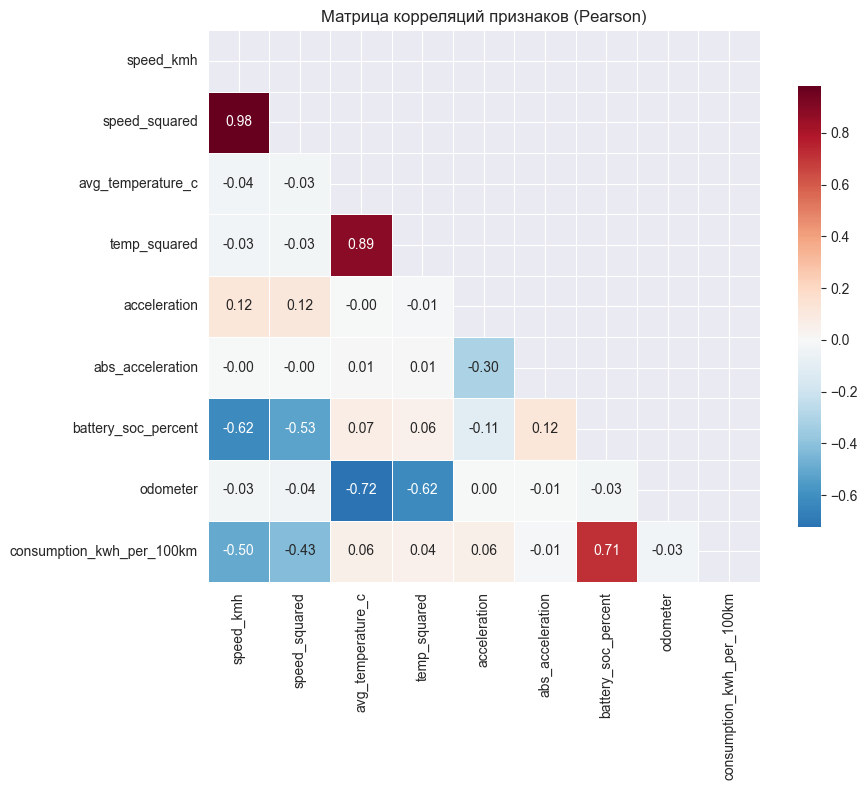


--- Корреляция с расходом энергии (|r|) ---
  battery_soc_percent: 0.710 (положительная)
  speed_kmh: 0.500 (отрицательная)
  speed_squared: 0.429 (отрицательная)
  avg_temperature_c: 0.058 (положительная)
  acceleration: 0.058 (положительная)
  temp_squared: 0.045 (положительная)
  odometer: 0.032 (отрицательная)
  abs_acceleration: 0.012 (отрицательная)

--- Мультиколлинеарность (r > 0.8) ---
  speed_kmh <-> speed_squared: 0.983
  avg_temperature_c <-> temp_squared: 0.888

--- Сравнение методов отбора признаков ---

Топ признаков по комбинированной оценке (корреляция + importance):
            Feature  Pearson_Correlation  Importance  Score
battery_soc_percent             0.709652    1.228647   1.00
          speed_kmh             0.500186    0.107042   3.00
      speed_squared             0.428652    0.133248   3.00
   abs_acceleration             0.011775    0.142588   5.00
       acceleration             0.057835    0.095591   5.00
  avg_temperature_c             0.058063    0.00

In [40]:
## БЛОК 3.5: КОРРЕЛЯЦИОННЫЙ АНАЛИЗ

print("\n=== КОРРЕЛЯЦИОННЫЙ АНАЛИЗ ===")

# Выбираем числовые признаки для корреляции
corr_features = [
    'speed_kmh', 'speed_squared', 'avg_temperature_c',
    'temp_squared', 'acceleration', 'abs_acceleration',
    'battery_soc_percent', 'odometer', 'consumption_kwh_per_100km'
]

# Фильтруем только существующие колонки
available_corr_features = [f for f in corr_features if f in df_sample.columns]

# Рассчитываем матрицу корреляций Пирсона
corr_matrix = df_sample[available_corr_features].corr()

# Визуализация тепловой карты
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Маска для верхнего треугольника
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title('Матрица корреляций признаков (Pearson)')
plt.tight_layout()
plt.show()

# Корреляция с целевой переменной (расход)
target_corr = corr_matrix['consumption_kwh_per_100km'].abs().sort_values(ascending=False)
print("\n--- Корреляция с расходом энергии (|r|) ---")
for feature, corr_val in target_corr.items():
    if feature != 'consumption_kwh_per_100km':
        direction = "положительная" if corr_matrix['consumption_kwh_per_100km'][feature] > 0 else "отрицательная"
        print(f"  {feature}: {corr_val:.3f} ({direction})")

# Выявление мультиколлинеарности (высокая корреляция между признаками)
print("\n--- Мультиколлинеарность (r > 0.8) ---")
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            feat1 = corr_matrix.columns[i]
            feat2 = corr_matrix.columns[j]
            corr_val = corr_matrix.iloc[i, j]
            high_corr_pairs.append((feat1, feat2, corr_val))
            print(f"  {feat1} <-> {feat2}: {corr_val:.3f}")

if not high_corr_pairs:
    print("  Сильной мультиколлинеарности не обнаружено")

# Сравнение с permutation importance
print("\n--- Сравнение методов отбора признаков ---")
comparison_df = pd.DataFrame({
    'Feature': available_corr_features[:-1],  # без целевой переменной
    'Pearson_Correlation': [abs(corr_matrix['consumption_kwh_per_100km'][f]) for f in available_corr_features[:-1]]
})
comparison_df = comparison_df.merge(
    feature_imp[['Feature', 'Importance']],
    on='Feature',
    how='outer'
).fillna(0)
comparison_df['Rank_Corr'] = comparison_df['Pearson_Correlation'].rank(ascending=False)
comparison_df['Rank_Importance'] = comparison_df['Importance'].rank(ascending=False)
comparison_df['Score'] = (comparison_df['Rank_Corr'] + comparison_df['Rank_Importance']) / 2
comparison_df = comparison_df.sort_values('Score')

print("\nТоп признаков по комбинированной оценке (корреляция + importance):")
print(comparison_df.head(10)[['Feature', 'Pearson_Correlation', 'Importance', 'Score']].to_string(index=False))

In [41]:
conn = sqlite3.connect(DB_PATH)

# Удаляем только "технические" колонки с кодировкой (_code), так как они дублируют информацию
# (road_type_code дублирует road_type)
cols_to_drop = [c for c in df.columns if c.endswith('_code')]
df_final = df.drop(columns=cols_to_drop)

print(f"[INFO] Сохраняем колонки: {df_final.columns.tolist()}")

# Записываем
df_final.to_sql('telematics_preprocessed', conn, if_exists='replace', index=False, chunksize=10000)
conn.close()

print(f"\n[SUCCESS] Очищенные данные сохранены в таблицу 'telematics_preprocessed'.")
print(f"[INFO] Всего признаков в финальном наборе: {len(df_final.columns)}")

[INFO] Сохраняем колонки: ['vehicle_id', 'timestamp', 'latitude', 'longitude', 'speed_kmh', 'battery_soc_percent', 'avg_temperature_c', 'acceleration', 'driving_style', 'road_type', 'odometer', 'consumption_kwh_per_100km', 'is_freezing', 'is_hot', 'temp_squared', 'speed_squared', 'abs_acceleration']

[SUCCESS] Очищенные данные сохранены в таблицу 'telematics_preprocessed'.
[INFO] Всего признаков в финальном наборе: 17


# А 4: БЛОК 0: НАСТРОЙКА SEABORN

In [42]:
sns.set(style="whitegrid")

## БЛОК 1: ЗАГРУЗКА И ГЛОБАЛЬНАЯ ОЧИСТКА ДАННЫХ

In [43]:
conn = sqlite3.connect(DB_PATH)
# Загружаем все данные из таблицы предобработанной телематики
query = "SELECT * FROM telematics_preprocessed"
df = pd.read_sql(query, conn)
conn.close()
df.replace([np.inf, -np.inf], np.nan, inplace=True)


### УДАЛЕНИЕ СТРОК С КРИТИЧЕСКИМИ ПРОПУСКАМИ

In [41]:
# Если нет расхода или скорости - строка бесполезна для анализа
initial_len = len(df)
df.dropna(subset=['consumption_kwh_per_100km', 'speed_kmh'], inplace=True)
print(f"Удалено строк с ошибочными значениями (inf/NaN): {initial_len - len(df):,}")

Удалено строк с ошибочными значениями (inf/NaN): 0


## БЛОК 2: СЛОВАРЬ ДАННЫХ (DATA DICTIONARY)

In [44]:
# Словарь с человекочитаемыми описаниями каждой колонки
ATTRIBUTES_DESCRIPTION = {
    'vehicle_id': 'Уникальный идентификатор электромобиля.',
    'timestamp': 'Временная метка записи телеметрии (YYYY-MM-DD HH:MM:SS).',
    'latitude': 'Широта (WGS 84). Координата местоположения.',
    'longitude': 'Долгота (WGS 84). Координата местоположения.',
    'speed_kmh': 'Скорость движения (км/ч). Влияет на аэродинамическое сопротивление.',
    'battery_soc_percent': 'Уровень заряда батареи (%). Ключевой фактор для расчета оставшегося хода.',
    'avg_temperature_c': 'Средняя температура воздуха (°C). Влияет на эффективность батареи.',
    'acceleration': 'Ускорение (м/с²). Положительное - разгон, отрицательные - торможение.',
    'driving_style': 'Стиль вождения (Aggressive, Normal, Cruising).',
    'road_type': 'Тип дороги (магистраль, городская улица и т.д.).',
    'odometer': 'Пробег автомобиля (км). Используется для расчета износа.',
    'consumption_kwh_per_100km': 'Расход энергии (кВт·ч на 100 км). Целевая метрика эффективности.',
    'is_freezing': 'Мороз (1/0). Температура < 0°C.',
    'is_hot': 'Жара (1/0). Температура > 30°C.',
    'temp_squared': 'Квадрат температуры (°C²). Для моделирования нелинейности.',
    'speed_squared': 'Квадрат скорости ((км/ч)²). Характеризует аэродинамику.',
    'abs_acceleration': 'Модуль ускорения (м/с²). Характеризует динамику движения.'
}

### ФИЛЬТРАЦИЯ И ВЫВОД ОПИСАНИЙ

In [45]:
# Создаём DataFrame из словаря для удобной фильтрации
desc_df = pd.DataFrame(
    list(ATTRIBUTES_DESCRIPTION.items()),
    columns=['Атрибут', 'Описание']
)
# Оставляем только существующие колонки
desc_df = desc_df[desc_df['Атрибут'].isin(df.columns)]

# Выводим в формате списка с маркерами
for index, row in desc_df.iterrows():
    print(f"• {row['Атрибут']}: {row['Описание']}")

print(f"\nВсего атрибутов в наборе: {len(df.columns)}")

• vehicle_id: Уникальный идентификатор электромобиля.
• timestamp: Временная метка записи телеметрии (YYYY-MM-DD HH:MM:SS).
• latitude: Широта (WGS 84). Координата местоположения.
• longitude: Долгота (WGS 84). Координата местоположения.
• speed_kmh: Скорость движения (км/ч). Влияет на аэродинамическое сопротивление.
• battery_soc_percent: Уровень заряда батареи (%). Ключевой фактор для расчета оставшегося хода.
• avg_temperature_c: Средняя температура воздуха (°C). Влияет на эффективность батареи.
• acceleration: Ускорение (м/с²). Положительное - разгон, отрицательные - торможение.
• driving_style: Стиль вождения (Aggressive, Normal, Cruising).
• road_type: Тип дороги (магистраль, городская улица и т.д.).
• odometer: Пробег автомобиля (км). Используется для расчета износа.
• consumption_kwh_per_100km: Расход энергии (кВт·ч на 100 км). Целевая метрика эффективности.
• is_freezing: Мороз (1/0). Температура < 0°C.
• is_hot: Жара (1/0). Температура > 30°C.
• temp_squared: Квадрат температ

## БЛОК 3: АНАЛИЗ НОРМАЛЬНОСТИ РАСПРЕДЕЛЕНИЙ

In [46]:
# Проверяем гипотезу о нормальности для ключевых признаков
print("\n=== АНАЛИЗ НОРМАЛЬНОСТИ ===")



=== АНАЛИЗ НОРМАЛЬНОСТИ ===


### АНАЛИЗ РАСХОДА (CONSUMPTION)


--- Анализ признака: Consumption (kWh/100km) ---
Примечание: Исключены нулевые значения (1302221 шт.), чтобы показать распределение АКТИВНОГО расхода.
Skewness: -0.278 | Kurtosis: -0.835
Shapiro-Wilk: p-value=0.00000 (Not Normal)


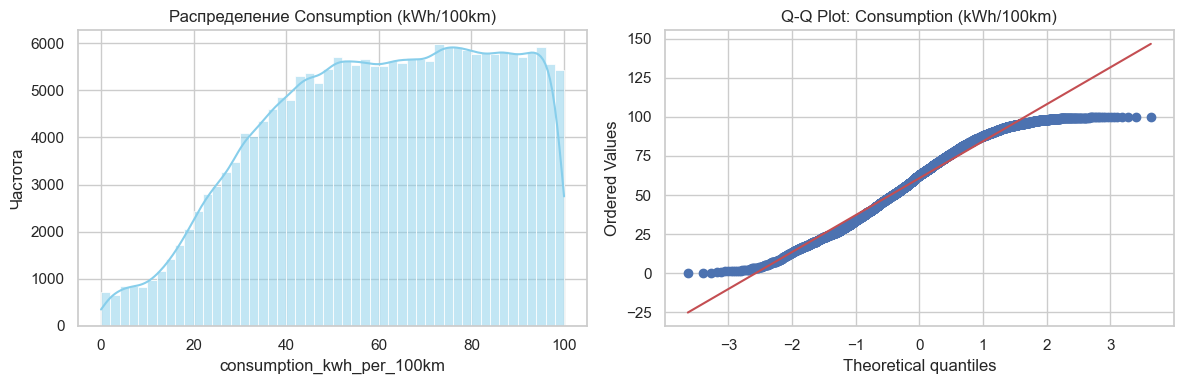

In [47]:
print("\n--- Анализ признака: Consumption (kWh/100km) ---")

# Выбираем серию данных для анализа
series = df['consumption_kwh_per_100km']
feature_name = 'Consumption (kWh/100km)'

# Предварительная очистка: удаляем NaN и бесконечности
clean_data = series.dropna()
clean_data = clean_data[~np.isinf(clean_data)]
# Нули соответствуют стоянию/покою и искажают визуализацию активного расхода
if 'consumption' in feature_name.lower():
    active_data = clean_data[clean_data > 0]
    if len(active_data) < len(clean_data):
        print(f"Примечание: Исключены нулевые значения ({len(clean_data)-len(active_data)} шт.), чтобы показать распределение АКТИВНОГО расхода.")
    clean_data = active_data

if len(clean_data) == 0:
    print(f"Нет данных для анализа {feature_name}.")
else:
    # Берём случайную выборку для теста Шапиро-Уилка (он чувствителен к размеру)
    sample = clean_data.sample(min(5000, len(clean_data)), random_state=42)

    # Вычисляем асимметрию (skewness) и эксцесс (kurtosis)
    print(f"Skewness: {clean_data.skew():.3f} | Kurtosis: {clean_data.kurtosis():.3f}")

    # Тест Шапиро-Уилка на нормальность
    # H0: данные распределены нормально. Если p > 0.05 - не отвергаем H0
    stat, p = stats.shapiro(sample)
    print(f"Shapiro-Wilk: p-value={p:.5f} {'(Normal)' if p > 0.05 else '(Not Normal)'}")

    # Создаём фигуру с двумя графиками
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Гистограмма с KDE (Kernel Density Estimation)
    sns.histplot(clean_data, kde=True, ax=axes[0], bins=50, color='skyblue')
    axes[0].set_title(f'Распределение {feature_name}')
    axes[0].set_ylabel('Частота')

    # Q-Q plot (квантиль-квантиль) для визуальной проверки нормальности
    stats.probplot(sample, dist="norm", plot=axes[1])
    axes[1].set_title(f'Q-Q Plot: {feature_name}')

    plt.tight_layout()
    plt.show()

    # Проверка эффекта логарифмирования для улучшения нормальности
    is_transformed = False
    if p < 0.05 and clean_data.skew() > 0.5:
        print(f">>> Попытка Логарифмирования...")
        # log1p = log(1 + x) чтобы избежать log(0) если остались нули
        log_data = np.log1p(clean_data)

        # Повторяем тест на логарифмированных данных
        stat_log, p_log = stats.shapiro(log_data.sample(min(5000, len(log_data)), random_state=42))
        print(f"Shapiro-Wilk (Log): p-value={p_log:.5f}")
        print(f"Skewness (Log): {log_data.skew():.3f}")

        # Сравниваем асимметрию до и после
        if abs(log_data.skew()) < abs(clean_data.skew()):
            print(">>> ВЫВОД: Логарифмирование УЛУЧШИЛО симметрию.")
            is_transformed = True



In [48]:
print("Графически распределение не нормальное")

Графически распределение не нормальное


### АНАЛИЗ СКОРОСТИ (SPEED)


--- Анализ признака: Speed (km/h) ---
Skewness: -0.091 | Kurtosis: -0.678
Shapiro-Wilk: p-value=0.00000 (Not Normal)


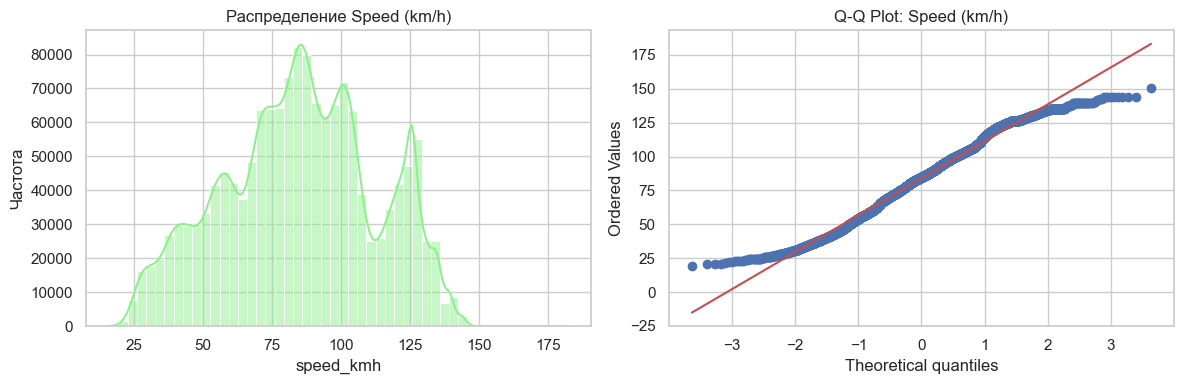

In [49]:
print("\n--- Анализ признака: Speed (km/h) ---")

series = df['speed_kmh']
feature_name = 'Speed (km/h)'

# Аналогичная очистка данных
clean_data = series.dropna()
clean_data = clean_data[~np.isinf(clean_data)]

# Для скорости не фильтруем нули (стояние - важная часть распределения)

if len(clean_data) == 0:
    print(f"Нет данных для анализа {feature_name}.")
else:
    sample = clean_data.sample(min(5000, len(clean_data)), random_state=42)

    print(f"Skewness: {clean_data.skew():.3f} | Kurtosis: {clean_data.kurtosis():.3f}")

    stat, p = stats.shapiro(sample)
    print(f"Shapiro-Wilk: p-value={p:.5f} {'(Normal)' if p > 0.05 else '(Not Normal)'}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.histplot(clean_data, kde=True, ax=axes[0], bins=50, color='lightgreen')
    axes[0].set_title(f'Распределение {feature_name}')
    axes[0].set_ylabel('Частота')

    stats.probplot(sample, dist="norm", plot=axes[1])
    axes[1].set_title(f'Q-Q Plot: {feature_name}')

    plt.tight_layout()
    plt.show()

    # Проверка логарифмирования
    is_transformed = False
    if p < 0.05 and clean_data.skew() > 0.5:
        print(f">>> Попытка Логарифмирования...")
        log_data = np.log1p(clean_data)

        stat_log, p_log = stats.shapiro(log_data.sample(min(5000, len(log_data)), random_state=42))
        print(f"Shapiro-Wilk (Log): p-value={p_log:.5f}")
        print(f"Skewness (Log): {log_data.skew():.3f}")

        if abs(log_data.skew()) < abs(clean_data.skew()):
            print(">>> ВЫВОД: Логарифмирование УЛУЧШИЛО симметрию.")
            is_transformed = True

In [50]:
print("Графически распределение нормальное")

Графически распределение нормальное


## БЛОК 4: АНАЛИЗ МАСШТАБА ПРИЗНАКОВ (SCALING)

In [51]:
# Определяем необходимость стандартизации для ML моделей
print("\n=== 2. АНАЛИЗ МАСШТАБА ПРИЗНАКОВ ===")
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Убираем идентификатор машины и бинарные признаки (у них свой масштаб 0/1)
features_to_scale = [c for c in num_cols if c not in ['vehicle_id', 'is_freezing', 'is_hot']]
# Среднее, стандартное отклонение, минимум, максимум
desc_stats = df[features_to_scale].describe().loc[['mean', 'std', 'min', 'max']]

print("Описательная статистика:")
print(desc_stats.T.head(10).to_string())
# Сравниваем диапазоны и стандартные отклонения
# Убираем константные признаки (std = 0) чтобы избежать деления на ноль
stds = desc_stats.loc['std']
stds = stds[stds > 0]

if not stds.empty:
    max_std = stds.max()
    min_std = stds.min()

    # Критерий: если разница в масштабах > 100 или есть очень большие значения (>10000)
    if max_std / min_std > 100 or max_std > 10000:
        print("1. Признаки имеют РАЗНЫЕ масштабы.")
        print("2. РЕКОМЕНДАЦИЯ: Применить StandardScaler (особенно для KNN, SVM, Linear Models).")
    else:
        print("1. Масштабы признаков сопоставимы.")
        print("2. РЕКОМЕНДАЦИЯ: Стандартизация желательна, но не критична.")
else:
    print("Недостаточно данных для оценки масштабов.")


=== 2. АНАЛИЗ МАСШТАБА ПРИЗНАКОВ ===
Описательная статистика:
                                    mean           std           min            max
latitude                       55.749955      0.103439     55.548969      55.953968
longitude                      37.622594      0.091164     37.414909      37.831730
speed_kmh                      84.849280     27.374595     16.000000     182.500000
battery_soc_percent            16.502490     25.250816      5.000000      99.709999
avg_temperature_c               6.739883     10.464079     -9.600000      28.500000
acceleration                   -0.002246      0.049004     -0.836111       0.710172
odometer                   108841.714607  48914.654592  12666.656250  261195.609375
consumption_kwh_per_100km       8.679544     23.130166      0.000000      99.999562
temp_squared                  154.922897    202.940473      0.010000     812.250000
speed_squared                7948.768267   4656.827548    256.000000   33306.250000
1. Признаки и

# А 5

## БЛОК 1: ЗАГРУЗКА ДАННЫХ ИЗ БД

In [52]:
conn = sqlite3.connect(DB_PATH)
# ВЫБОРКА ДАННЫХ ДЛЯ АУГМЕНТАЦИИ
# Берём случайную выборку 50,000 записей для демонстрации метода
query = """
SELECT
    vehicle_id,
    timestamp,
    latitude,
    longitude,
    speed_kmh,
    avg_temperature_c,
    consumption_kwh_per_100km,
    driving_style,
    road_type
FROM telematics_preprocessed
ORDER BY RANDOM()
LIMIT 50000
"""

df = pd.read_sql(query, conn)
# Сортируем по ID машины и времени для корректного расчёта расстояний
df = df.sort_values(by=['vehicle_id', 'timestamp']).reset_index(drop=True)
print(f"Загружено шаблонов для аугментации: {len(df):,}")

Загружено шаблонов для аугментации: 50,000


## БЛОК 2: ДОПОЛНЕНИЕ ВНЕШНЕЙ ИНФОРМАЦИЕЙ (ENRICHMENT)

In [54]:
# РАСЧЁТ РАССТОЯНИЯ МЕЖДУ ТОЧКАМИ
# Сдвигаем координаты на 1 шаг вниз, чтобы получить "следующую точку"
lat_next = df['latitude'].shift(-1)
lon_next = df['longitude'].shift(-1)

# Векторизированный расчёт расстояния между двумя точками (в метрах)
# Формула гаверсинусов для сферической геометрии
R = 6371000  # Радиус Земли в метрах

# Конвертируем градусы в радианы
lat1_rad = np.radians(df['latitude'])
lon1_rad = np.radians(df['longitude'])
lat2_rad = np.radians(lat_next)
lon2_rad = np.radians(lon_next)

# Разницы координат
dlat = lat2_rad - lat1_rad
dlon = lon2_rad - lon1_rad

# Формула гаверсинусов
a = np.sin(dlat/2)**2 + np.cos(lat1_rad) * np.cos(lat2_rad) * np.sin(dlon/2)**2
c = 2 * np.arcsin(np.sqrt(a))

# Расстояние в метрах
df['segment_distance_m'] = R * c

# Последняя точка каждого маршрута имеет NaN (нет следующей точки), заполняем 0
df['segment_distance_m'].fillna(0, inplace=True)
# ИМИТАЦИЯ ПЕРЕПАДА ВЫСОТ
np.random.seed(42)  # Фиксируем seed для воспроизводимости
# Случайный подъём 0-0.5 метра на каждый сегмент
df['elevation_gain_m'] = np.random.uniform(0, 0.5, size=len(df))
# ИМИТАЦИЯ ПОГОДНЫХ УСЛОВИЙ
# Осадки: только если температура > 0°C (дождь), иначе 0 (снег не моделируем)
precip_condition = df['avg_temperature_c'] > 0
df['precipitation_mm'] = np.where(
    precip_condition,
    np.random.uniform(0, 2.0, size=len(df)),  # 0-2 мм осадков
    0
)

# Ветер: абсолютное значение нормального распределения (среднее 3 м/с, std=2)
df['wind_speed_ms'] = np.abs(np.random.normal(3, 2, size=len(df)))

print("Добавлены колонки: segment_distance_m, elevation_gain_m, precipitation_mm, wind_speed_ms")

Добавлены колонки: segment_distance_m, elevation_gain_m, precipitation_mm, wind_speed_ms


## БЛОК 3: АУГМЕНТАЦИЯ

In [55]:
synthetic_rows = []

# Генерируем 2 синтетические вариации для каждой исходной строки
for i in range(2):
    # Создаём копию исходных данных
    df_copy = df.copy()# Создаём список для хранения синтетических вариаций
    # Множитель скорости: 0.8 - 1.3 (от -20% до +30% от базовой скорости)
    speed_factor = np.random.uniform(0.8, 1.3, size=len(df_copy))

    # Изменение температуры: от -10°C до +10°C
    temp_delta = np.random.uniform(-10, 10, size=len(df_copy))
    # Создаём списки для результатов
    new_consumptions = []
    new_speeds = []
    new_temps = []

    # Итерируем по строкам DataFrame
    for idx, row in df_copy.iterrows():
        base_cons = row['consumption_kwh_per_100km']
        base_temp = row['avg_temperature_c']
        base_speed = row['speed_kmh']

        # Получаем множители для текущей строки
        sf = speed_factor[idx]
        td = temp_delta[idx]

        # --- Физическая модель пересчёта ---

        # 1. Влияние изменения скорости
        # Сопротивление воздуха ~ v^2, мощность ~ v^3
        # Используем степень 1.5 как усреднённую для смешанного цикла
        new_speed = base_speed * sf
        # Защита от деления на ноль
        if base_speed > 0:
            speed_effect = (new_speed / base_speed) ** 1.5
        else:
            speed_effect = 1.0

        # 2. Влияние изменения температуры
        new_temp = base_temp + td
        temp_effect = 1.0

        # Если температура падает ниже нуля: обогрев + плохая химия батареи = +10-30% расхода
        if new_temp < 0 and base_temp >= 0:
            temp_effect = np.random.uniform(1.1, 1.3)
        # Если очень жарко (>30°C): кондиционер = +10-15% расхода
        elif new_temp > 30:
            temp_effect = np.random.uniform(1.1, 1.15)

        # Итоговый расход с применением эффектов
        new_cons = base_cons * speed_effect * temp_effect

        # Защита от физически невозможных значений
        # Ограничиваем разумными пределами 5 - 150 кВтч/100км
        new_cons = np.clip(new_cons, 5.0, 150.0)

        new_consumptions.append(new_cons)
        new_speeds.append(new_speed)
        new_temps.append(new_temp)

    # Записываем результаты в копию DataFrame
    df_copy['consumption_kwh_per_100km'] = new_consumptions
    df_copy['speed_kmh'] = new_speeds
    df_copy['avg_temperature_c'] = new_temps
    # Помечаем как синтетические и обновляем бинарные индикаторы температуры
    df_copy['is_synthetic'] = 1  # 1 = синтетические данные
    # Обновляем бинарные флаги на основе новой температуры
    df_copy['is_freezing'] = (df_copy['avg_temperature_c'] < 0).astype(int)
    df_copy['is_hot'] = (df_copy['avg_temperature_c'] > 30).astype(int)

    # Добавляем в список синтетических наборов
    synthetic_rows.append(df_copy)

# Маркируем исходные данные как реальные (не синтетические)
df['is_synthetic'] = 0

# Объединяем: исходные данные + все синтетические вариации
final_df = pd.concat([df] + synthetic_rows, ignore_index=True)

print(f"Создано строк: {len(final_df):,} (Включая синтетику)")

Создано строк: 150,000 (Включая синтетику)


## БЛОК 4: СОХРАНЕНИЕ РАСШИРЕННОГО НАБОРА

In [56]:
# Запись чанками по 10,000 строк для экономии памяти
final_df.to_sql(
    'telematics_augmented',
    conn,
    if_exists='replace',
    index=False,
    chunksize=10000
)

conn.close()

## БЛОК 5: ВЫВОД СТАТИСТИКИ

In [57]:
print("\n=== СТАТИСТИКА РАСШИРЕНИЯ ===")
print(final_df[['is_synthetic', 'segment_distance_m', 'elevation_gain_m']].describe())


=== СТАТИСТИКА РАСШИРЕНИЯ ===
        is_synthetic  segment_distance_m  elevation_gain_m
count  150000.000000       150000.000000     150000.000000
mean        0.666667         3343.366316          0.249432
std         0.471406         6558.155350          0.144202
min         0.000000            0.000000          0.000003
25%         0.000000          218.111806          0.124455
50%         1.000000          656.873413          0.249446
75%         1.000000         2378.233887          0.374151
max         1.000000        46475.582892          0.499986
